# Introduction to Data Science 2026

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [85]:
#i had help from Gemini helping with checking for correctness, and improving the code
import pandas as pd
import numpy as np
import ast

In [2]:
teds = pd.read_csv("./ex6/ted_main.csv")
teds["ratings"] = teds["ratings"].apply(ast.literal_eval)
# teds["tags"]
# teds["ratings"][0], #np.shape(teds["ratings"])
teds


,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,17,"Between 2008 and 2016, the United States depor...",476,TED2017,1496707200,4,Duarte Geraldino,Duarte Geraldino: What we're missing in the de...,1,1505851216,"[{'id': 3, 'name': 'Courageous', 'count': 24},...","[{'id': 2596, 'hero': 'https://pe.tedcdn.com/i...",Journalist,"['TED Residency', 'United States', 'community'...",What we're missing in the debate about immigra...,https://www.ted.com/talks/duarte_geraldino_wha...,450430
2546,6,How can you study Mars without a spaceship? He...,290,TED2017,1492992000,3,Armando Azua-Bustos,Armando Azua-Bustos: The most Martian place on...,1,1505919737,"[{'id': 22, 'name': 'Fascinating', 'count': 32...","[{'id': 2491, 'hero': 'https://pe.tedcdn.com/i...",Astrobiologist,"['Mars', 'South America', 'TED Fellows', 'astr...",The most Martian place on Earth,https://www.ted.com/talks/armando_azua_bustos_...,417470
2547,10,Science fiction visions of the future show us ...,651,TED2017,1492992000,1,Radhika Nagpal,Radhika Nagpal: What intelligent machines can ...,1,1506006095,"[{'id': 1, 'name': 'Beautiful', 'count': 14}, ...","[{'id': 2346, 'hero': 'https://pe.tedcdn.com/i...",Robotics engineer,"['AI', 'ants', 'fish', 'future', 'innovation',...",What intelligent machines can learn from a sch...,https://www.ted.com/talks/radhika_nagpal_what_...,375647
2548,32,In an unmissable talk about race and politics ...,1100,TEDxMileHigh,1499472000,1,Theo E.J. Wilson,Theo E.J. Wilson: A black man goes undercover ...,1,1506024042,"[{'id': 11, 'name': 'Longwinded', 'count': 3},...","[{'id': 2512, 'hero': 'https://pe.tedcdn.com/i...",Public intellectual,"['Internet', 'TEDx', 'United States', 'communi...",A black man goes undercover in the alt-right,https://www.t

In [3]:
#grab ratings
#upgraded version
def get_count(ratings_list, name):
    for rating in ratings_list:
        if rating["name"] == name:
            return rating["count"]
    return 0


# Assign columns cleanly in one pass
for category in ["Funny", "Confusing", "Inspiring"]:
    teds[category] = teds["ratings"].apply(
        lambda r: get_count(r, category)
    )

teds["Funny"]

0       19645
1         544
2         964
3          59
4        1390
        ...  
2545        1
2546       20
2547        1
2548       63
2549        0
Name: Funny, Length: 2550, dtype: int64

In [ ]:

    #slow version
# funny_ratings = []
# confusing_ratings = [] 
# inspiring_ratings = []
# for ratings in teds["ratings"]:
#     for rating in ratings:
#         if rating["name"] == "Funny":
#             funny_ratings.append(rating["count"])
#         if rating["name"] == "Confusing":
#             confusing_ratings.append(rating["count"])
            
#         if rating["name"] == "Inspiring":
#             inspiring_ratings.append(rating["count"])

# teds["funny"] = funny_ratings
# teds["confusing"] = confusing_ratings
# teds["inspiring"] = inspiring_ratings

In [38]:
from collections import Counter
teds['tags'] = teds['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
tag_counts = pd.Series(Counter([tag for sublist in teds['tags'] for tag in sublist]))
tag_counts = tag_counts.sort_values(ascending=False)
top_100_tags = tag_counts[:100].index.tolist()

encoded_tags_df = pd.DataFrame(
    [[1 if tag in row_tags else 0 for tag in top_100_tags] for row_tags in teds["tags"]],
    columns=top_100_tags,
    index=teds.index
)

base_cols = ['views', 'Funny', 'Confusing', 'Inspiring']
teds_104 = pd.concat([teds[base_cols], encoded_tags_df], axis=1)
teds_104

,views,Funny,Confusing,Inspiring,technology,science,global issues,culture,TEDx,design,...,food,religion,peace,family,ecology,demo,poetry,illness,universe,energy
0,47227110,19645,242,24924,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3200520,544,62,413,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1636292,964,27,230,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1697550,59,32,1070,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12005869,1390,72,2893,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,450430,1,2,27,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2546,417470,20,0,20,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2547,375647,1,5,30,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2548,419309,63,1,147,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [77]:
#views
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

train_exclude = ["views", "Funny", "Confusing", "Inspiring"]
X = np.array(teds_104.drop(train_exclude, axis=1))            
y_views = np.array(teds_104["views"])
X_train_views, X_test_views, y_train_views, y_test_views = train_test_split(X, y_views, test_size=0.2, random_state=42)
model_views = LinearRegression()
model_views.fit(X_train_views, y_train_views)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](100,)","[-253668.78,-154001.57,-359699.56,..., 809173.52, 372741.86, -98844.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.93e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,100
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(100)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](100,)","[25.83,22.71,21.14,..., 4.88, 4.68, 4.37]"


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [62]:
#funny
y_funny = np.array(teds_104["Funny"])
X_train_funny, X_test_funny, y_train_funny, y_test_funny = train_test_split(X, y_funny, test_size=0.2, random_state=42)
model_funny = LinearRegression()
model_funny.fit(X_train_funny, y_train_funny)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](100,)","[-30.43, -0.17,-63.05,..., 34.65,-32.1 , -0.41]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,127
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,100
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(100)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](100,)","[25.83,22.71,21.14,..., 4.88, 4.68, 4.37]"


In [63]:
#confusing
y_confusing = np.array(teds_104["Confusing"])
X_train_confusing, X_test_confusing, y_train_confusing, y_test_confusing = train_test_split(X, y_confusing, test_size=0.2, random_state=42)
model_confusing = LinearRegression()
model_confusing.fit(X_train_confusing, y_train_confusing)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](100,)","[-0.6 , 6.39,-0.43,..., 7.97, 2.09,-2.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,20.67
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,100
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(100)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](100,)","[25.83,22.71,21.14,..., 4.88, 4.68, 4.37]"


In [64]:
#inspiring
y_inspiring = np.array(teds_104["Inspiring"])
X_train_inspiring, X_test_inspiring, y_train_inspiring, y_test_inspiring = train_test_split(X, y_inspiring, test_size=0.2, random_state=42)
model_inspiring = LinearRegression()
model_inspiring.fit(X_train_inspiring, y_train_inspiring)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](100,)","[-180.84,-138.86, -28.06,..., 523.08, -7.96, 76.93]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,571.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,100
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(100)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](100,)","[25.83,22.71,21.14,..., 4.88, 4.68, 4.37]"


In [67]:
from sklearn.metrics import mean_squared_error, r2_score
predictions_views = model_views.predict(X_test_views)
predictions_funny = model_funny.predict(X_test_funny)
predictions_confusing = model_confusing.predict(X_test_confusing)
predictions_inspiring = model_inspiring.predict(X_test_inspiring)


# Assuming you have models and test splits ready, example for views:
# (Make sure to generate predictions using X_test for each model)
# y_pred_views = model_views.predict(X_test_views) # use your specific X_test variable

print("Views Model - R2:", r2_score(y_test_views, predictions_views))
print("Views Model - RMSE:", np.sqrt(mean_squared_error(y_test_views, predictions_views)))

print("Funny Model - R2:", r2_score(y_test_funny, predictions_funny))
print("Funny Model - RMSE:", np.sqrt(mean_squared_error(y_test_funny, predictions_funny)))

print("Confusing Model - R2:", r2_score(y_test_confusing, predictions_confusing))
print("Confusing Model - RMSE:", np.sqrt(mean_squared_error(y_test_confusing, predictions_confusing)))

print("Inspiring Model - R2:", r2_score(y_test_inspiring, predictions_inspiring))
print("Inspiring Model - RMSE:", np.sqrt(mean_squared_error(y_test_inspiring, predictions_inspiring)))

Views Model - R2: 0.16447843122943084
Views Model - RMSE: 1801221.5401485171
Funny Model - R2: 0.2093054993393716
Funny Model - RMSE: 325.8434805509552
Confusing Model - R2: 0.18953655784818535
Confusing Model - RMSE: 27.08909130838316
Inspiring Model - R2: 0.07712709702403331
Inspiring Model - RMSE: 920.5725868105575


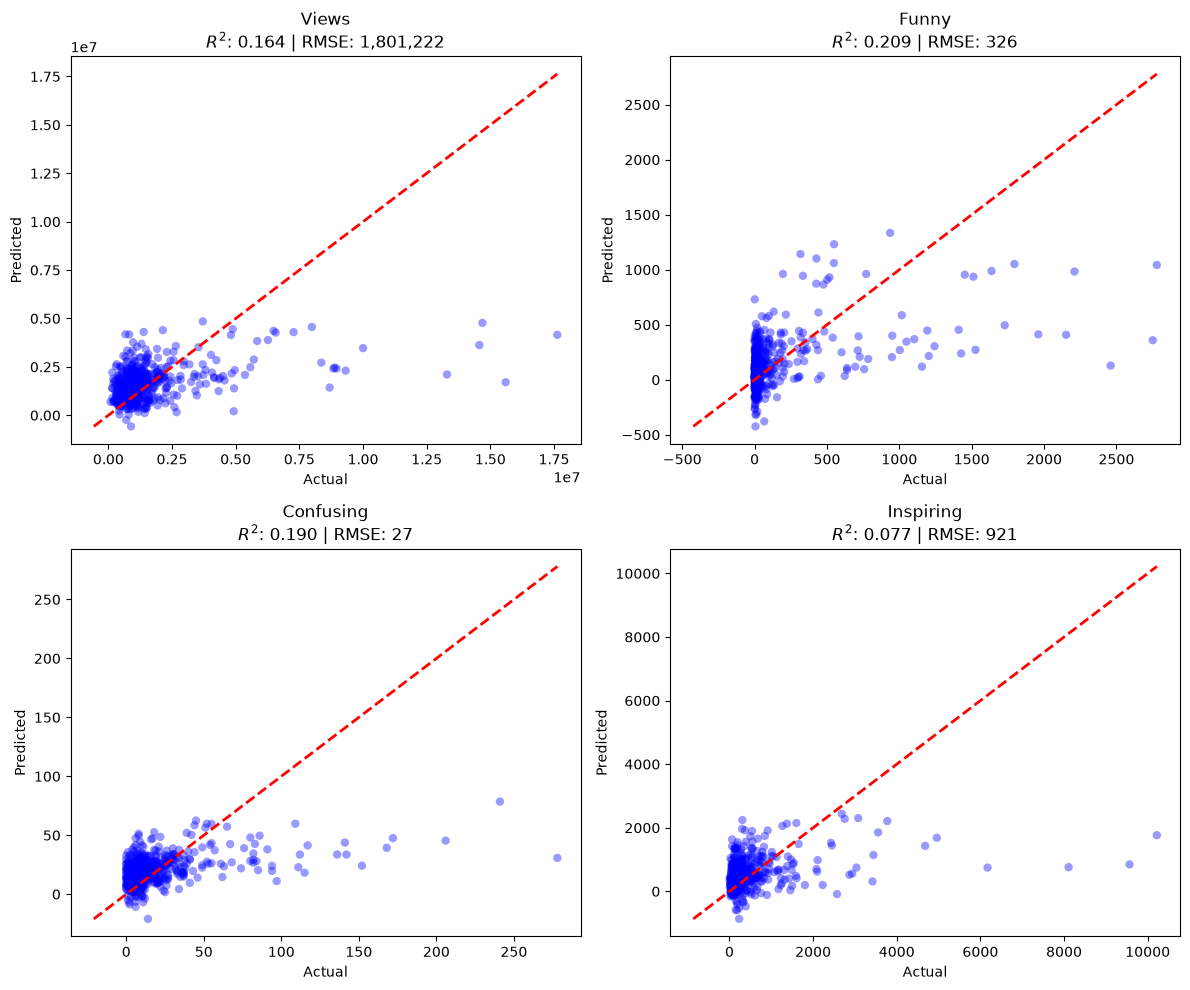

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Organize models and data in a dictionary for clean looping
targets = {
    'Views': (y_test_views, model_views.predict(X_test_views)),
    'Funny': (y_test_funny, model_funny.predict(X_test_funny)),
    'Confusing': (y_test_confusing, model_confusing.predict(X_test_confusing)),
    'Inspiring': (y_test_inspiring, model_inspiring.predict(X_test_inspiring))
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, (y_true, y_pred)) in enumerate(targets.items()):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Scatter plot
    axes[i].scatter(y_true, y_pred, alpha=0.4, color='blue', edgecolors='none')
    
    # 45-degree reference line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    # Labels & Title
    axes[i].set_title(f"{name}\n$R^2$: {r2:.3f} | RMSE: {rmse:,.0f}")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.show()
#underprediction, only ~8-21% explained by binary tags. neg predictions weird

4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [90]:
from sklearn.linear_model import LassoCV

lasso_views = LassoCV(cv=5).fit(X, y_views)

X_df = teds_104.drop(train_exclude, axis=1)   
# Extract top predictor tags with non-zero coefficients
selected_tags = pd.Series(lasso_views.coef_, index=X_df.columns)
important_tags = selected_tags[selected_tags != 0].sort_values(ascending=False)

print("Top tags predicting views:")
print(important_tags)
#positive values => high views above baseline
#negative values => low views below baseline


Top tags predicting views:
psychology       1.547282e+06
work             7.895974e+05
motivation       5.747320e+05
culture          5.642394e+05
brain            4.908181e+05
demo             4.324695e+05
humor            2.986529e+05
education        2.924200e+05
business         2.702778e+05
mental health    2.585914e+05
creativity       1.477540e+05
happiness        1.019289e+05
entertainment    2.596712e+04
writing          1.731498e+04
communication    1.693232e+04
neuroscience    -8.700204e+03
Africa          -1.696072e+04
society         -2.623843e+04
environment     -5.743523e+04
community       -6.525803e+04
collaboration   -7.397083e+04
music           -8.295998e+04
history         -8.318876e+04
TED Fellows     -9.562284e+04
TEDx            -1.056554e+05
cities          -1.397199e+05
technology      -1.421418e+05
activism        -1.530374e+05
science         -1.592471e+05
war             -1.596691e+05
health care     -1.670413e+05
economics       -2.262338e+05
politics     

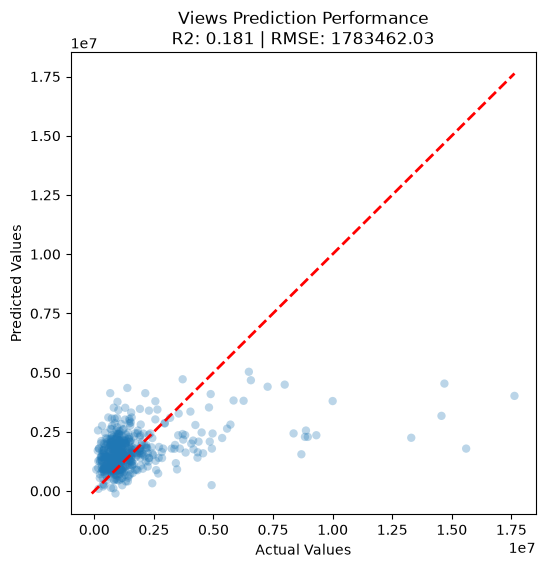

In [91]:
X_upgraded = np.array(teds_104[important_tags.index])
X_train_views_upgraded, X_test_views_upgraded, y_train_views_upgraded, y_test_views_upgraded = train_test_split(X_upgraded, y_views, test_size=0.2, random_state=42)
model_views_upgraded = LinearRegression()
model_views_upgraded.fit(X_train_views_upgraded, y_train_views_upgraded)

def evaluate_and_plot(y_true, y_pred, title):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, edgecolors='none')
    
    # Draw 45-degree perfect prediction line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{title}\nR2: {r2:.3f} | RMSE: {rmse:.2f}")
    plt.show()

evaluate_and_plot(y_test_views_upgraded, model_views_upgraded.predict(X_test_views_upgraded), "Views Prediction Performance")
#mild improvements

In [92]:
X_tags = np.array(X_df)

# 2. List of rating targets to evaluate
rating_targets = ["Funny", "Confusing", "Inspiring"]

# Dictionary to store the non-zero tags for each rating target
important_tags_by_rating = {}

for rating in rating_targets:
    y_rating = np.array(teds_104[rating])
    
    # Fit LASSO with 5-fold cross-validation
    lasso_model = LassoCV(cv=5, random_state=42).fit(X_tags, y_rating)
    
    # Extract non-zero coefficient tags
    selected_tags = pd.Series(lasso_model.coef_, index=X_df.columns)
    important_tags = selected_tags[selected_tags != 0].sort_values(ascending=False)
    
    # Save results to dictionary
    important_tags_by_rating[rating] = important_tags
    
    # Print results
    print(f"\n--- Top Tags Predicting: {rating} (Total Selected: {len(important_tags)}) ---")
    print("Positive Predictors (Top 5):")
    print(important_tags.head(5))
    print("\nNegative Predictors (Top 5):")
    print(important_tags.tail(5))


--- Top Tags Predicting: Funny (Total Selected: 16) ---
Positive Predictors (Top 5):
humor            713.548161
entertainment    123.734456
psychology       119.639188
work             110.651047
culture          110.321900
dtype: float64

Negative Predictors (Top 5):
music            -7.298879
technology      -15.850694
art             -32.034914
design          -40.382721
global issues   -58.422386
dtype: float64

--- Top Tags Predicting: Confusing (Total Selected: 71) ---
Positive Predictors (Top 5):
evolution     16.194701
philosophy    15.329317
religion      12.876535
physics       12.636922
psychology    11.316565
dtype: float64

Negative Predictors (Top 5):
oceans       -5.767174
music        -5.839085
innovation   -6.211614
Africa       -6.244186
animals      -6.511798
dtype: float64

--- Top Tags Predicting: Inspiring (Total Selected: 22) ---
Positive Predictors (Top 5):
psychology       694.919514
work             447.515318
mental health    436.239432
education        360

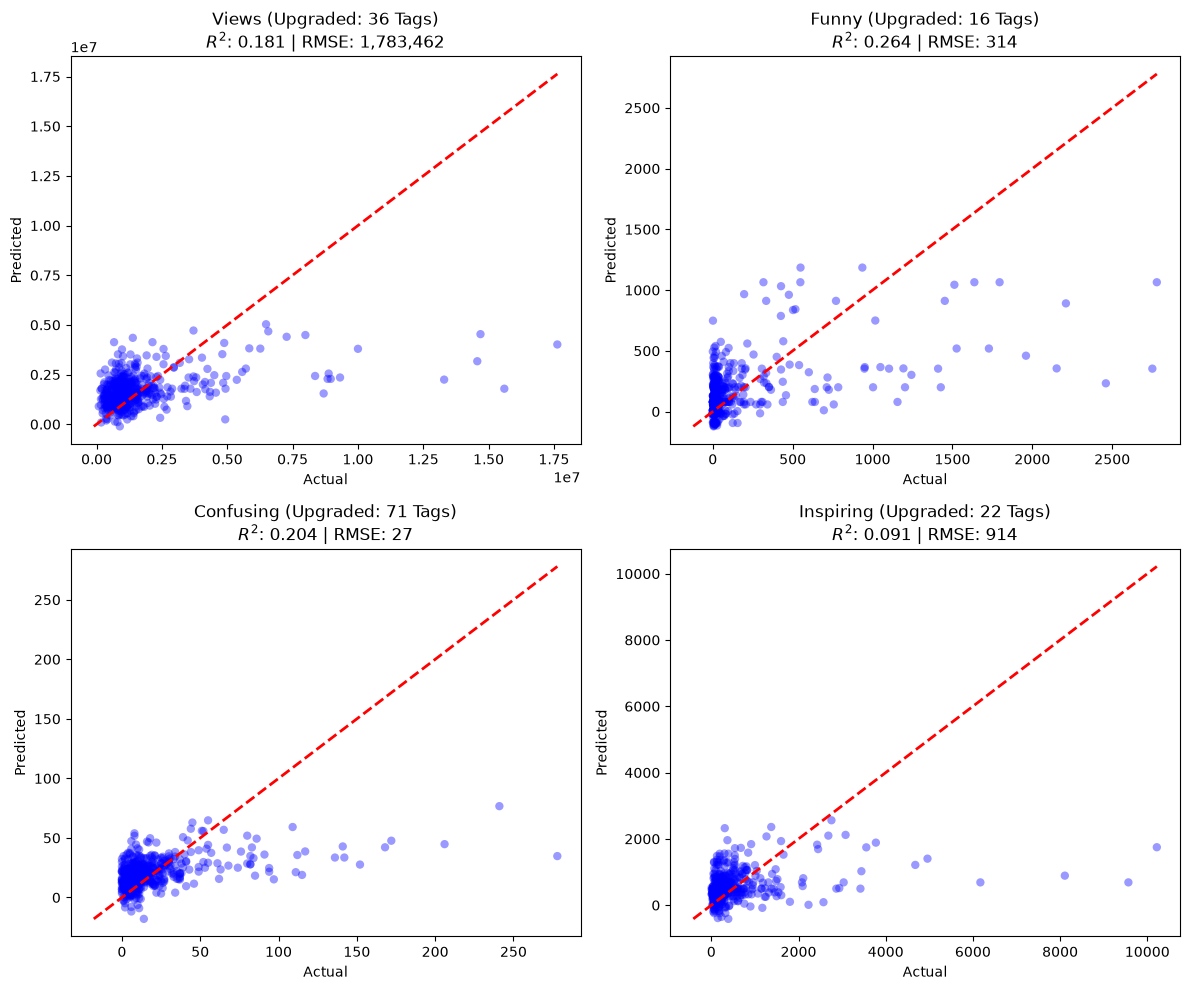

In [95]:
#Gemini's plot for visualization
# 1. Define feature matrix X and targets
train_exclude = ["views", "Funny", "Confusing", "Inspiring"]
X_df = teds_104.drop(columns=train_exclude)
X = np.array(X_df)

targets = ["views", "Funny", "Confusing", "Inspiring"]
pruned_tags_dict = {}

# 2. Run LASSO for ALL 4 targets and store their specific pruned tags
for target in targets:
    y_target = np.array(teds_104[target])

    lasso = LassoCV(cv=5, random_state=42).fit(X, y_target)

    # Filter out zero-coefficient features
    coef_series = pd.Series(lasso.coef_, index=X_df.columns)
    selected = coef_series[coef_series != 0]

    # Save to dictionary using the target name as key
    pruned_tags_dict[target] = selected

# 3. Plot upgraded Linear Regression models using each target's specific pruned tags
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, target in enumerate(targets):
    # Retrieve the exact selected tags for THIS target
    selected_tags = pruned_tags_dict[target]

    X_pruned = teds_104[selected_tags.index]
    y_target = teds_104[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X_pruned, y_target, test_size=0.2, random_state=42
    )

    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Scatter plot
    axes[i].scatter(y_test, y_pred, alpha=0.4, color="blue", edgecolors="none")

    # 45-degree reference line
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

    axes[i].set_title(
        f"{target.capitalize()} (Upgraded: {len(selected_tags)} Tags)\n$R^2$: {r2:.3f} | RMSE: {rmse:,.0f}"
    )
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

the initial results show underprediction, only ~8-21% explained by binary tags. neg predictions seem odd (can't exactly have negative views).

With the LASSO pruning, we find tags that seem to positively correlate with higher views and lower views.
The top 5 higher view tags are: psychology, work, motivation, culture, and brain.
The top 5 lower view tags are: global issues, art, design, politics, and economics.

For ratings we have:

**Funny**:
humor            
entertainment    
psychology       
work             
culture          

**Not Funny**:
music           
technology      
art             
design          
global issues   

**Confusing**:
evolution     
philosophy    
religion      
physics       
psychology    


**Not Confusing**:
oceans       
music        
innovation   
Africa       
animals   


**Inspiring**:
psychology     
work           
mental health  
education      
happiness             

**Not Inspiring**:
neuroscience    
technology     
art            
science        
economics       

---

- it's interesting how neuroscience, tech and science aren't inspiring. very peculiar.
- even with improvements, all showed only mild improvements. perhaps tags aren't that great at predicting the outcomes




**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [96]:
import pandas as pd
import numpy as np
from PIL import Image

In [101]:
#processed data
hasy = pd.read_csv("./ex3/hasy/hasy-data-labels.csv")
hasy_filtered = hasy[(hasy["symbol_id"] >= 70) & (hasy["symbol_id"] <= 79)]
start_path = "./ex3/hasy/"
img_paths = np.array(hasy_filtered["path"])
all_images = np.array([np.array(Image.open(start_path+img).convert('L')).flatten() for img in img_paths])
labels = np.array(hasy_filtered["symbol_id"])


In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    all_images, labels, test_size=0.2, random_state=42, stratify=labels
)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Default Random Forest Accuracy: {accuracy * 100:.2f}%")
#decent performance, not as good as the ~87% of the logistic regression one

Default Random Forest Accuracy: 83.33%


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

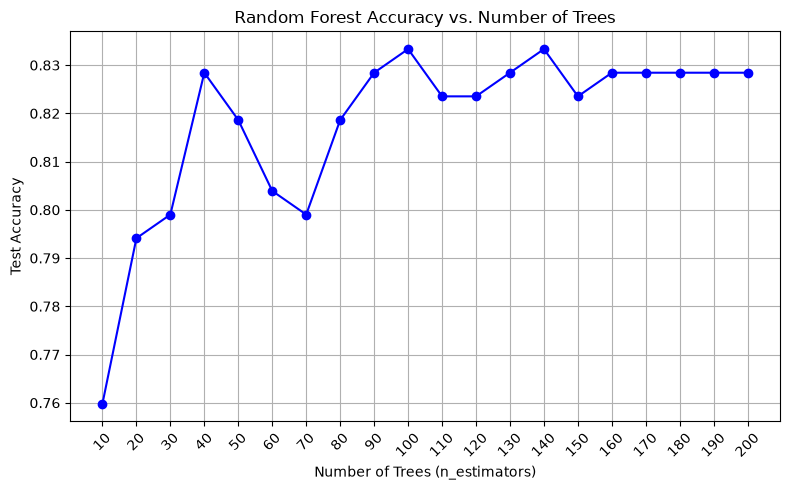

In [117]:
accuracies = []
tree_counts = [10 * i for i in range(1, 21)]
for trees in tree_counts:
    rf_clf = RandomForestClassifier(n_estimators=trees, random_state=42)
    
    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    

# 3. Plot Test Accuracy vs. Number of Trees
plt.figure(figsize=(8, 5))
plt.plot(tree_counts, accuracies, marker='o', linestyle='-', color='b')
plt.title("Random Forest Accuracy vs. Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.xticks(tree_counts, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
#the accuracy goes up until about 100 trees (~83.3%)
#then it goes a bit down and stabilizes around ~82.8% accuracy


3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

Test data and test accuracy only measures one type of accuracy, which is the test accuracy, but there's also the training accuracy that needs to be considered. Test accuracy alone can't generalize well. There needs to be a balance. It could also be just a lucky test set that we picked, meaning it didn't generalize, just lucky.

4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

In [121]:
#Gemini provided, I had no clue what I was doing anymore
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, labels, 
    test_size=0.20, 
    random_state=42, 
    shuffle=True, 
    stratify=labels
)

# Step 2: Split the 20% Temp equally (50% / 50%) into Val and Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    shuffle=True, 
    stratify=y_temp
)


param_grid = [
    {'n_estimators': 50,  'max_depth': 10,   'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': 15,   'min_samples_split': 2},
    {'n_estimators': 150, 'max_depth': 20,   'min_samples_split': 5},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5},
]


best_val_accuracy = 0.0
best_model = None
best_params = None

# 4. Tune hyperparameters using ONLY training and validation sets
for params in param_grid:
    clf = RandomForestClassifier(**params, random_state=42)
    clf.fit(X_train, y_train)
    
    val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    
    print(f"Params: {params} | Val Accuracy: {val_acc * 100:.2f}%")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model = clf
        best_params = params

print(f"\nBest Validation Accuracy: {best_val_accuracy * 100:.2f}%")
print(f"Best Hyperparameters: {best_params}")

# 5. Final evaluation on the unseen test set
test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Final Test Accuracy (Unbiased): {test_acc * 100:.2f}%")

Params: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2} | Val Accuracy: 84.31%
Params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2} | Val Accuracy: 87.25%
Params: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 5} | Val Accuracy: 88.24%
Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2} | Val Accuracy: 86.27%
Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5} | Val Accuracy: 87.25%

Best Validation Accuracy: 88.24%
Best Hyperparameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 5}
Final Test Accuracy (Unbiased): 80.39%


the model seems to generalize better. the test accuracy is down by ~3%, but the validation accuracy is relatively high at ~88%. we should be more confident that this model will perform better on real world data. we could potentially look into changing the values for max_depth and min_samples_split to find even better results for the 150 trees. Or maybe even search within a +-10 trees range of the 150.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [143]:
from sklearn.preprocessing import LabelEncoder
import tpot

le = LabelEncoder()
y_encoded = le.fit_transform(labels)

X_train, X_temp, y_train, y_temp = train_test_split(all_images, y_encoded, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X, y = X_train, y_train
est = tpot.TPOTClassifier()
est.fit(X,y)

Generation: : 2it [1:00:05, 1802.53s/it]
/home/santa/Documents/github-repos/dsi-exercises/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/santa/Documents/github-repos/dsi-exercises/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/santa/Documents/github-repos/dsi-exercises/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_it

,search_space,<tpot.search_...x7fec33b646e0>
,scorers,['roc_auc_ovr']
,scorers_weights,[1]
,cv,10
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False


In [147]:
pred_val = est.predict(X_val)

pred_test = est.predict(X_test)
accuracy_score(y_val, pred_val), \
accuracy_score(y_test, pred_test)

#the validation accuracy is ~88% while the test accuracy is ~89%.
#These aren't that different from the tree based approach (The test acc is ~8% higher, but the validaton is the same).

(0.8823529411764706, 0.8921568627450981)

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**